In [1]:
import json
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle

# Load the annotations and images data
with open('train.json') as f:
    data = json.load(f)

annotations = pd.DataFrame(data['annotations'])
images = pd.DataFrame(data['images'])

print(annotations)

      id  image_id  category_id                   bbox    area  iscrowd  \
0      1     28642            1  [1275, 725, 203, 124]   25172        0   
1      2     28642            1   [824, 475, 174, 127]   22182        0   
2      3     28661            1  [1296, 746, 202, 124]   25039        0   
3      4     28661            1   [824, 484, 174, 129]   22397        0   
4      5     28681            1  [1482, 775, 245, 118]   28775        0   
..   ...       ...          ...                    ...     ...      ...   
965  966     38601            1    [84, 699, 294, 174]   51127        0   
966  967     38601            1    [747, 558, 100, 58]    5832        0   
967  968     38621            1   [228, 659, 384, 287]  110310        0   
968  969     38621            1   [318, 768, 279, 230]   64175        0   
969  970     38621            1    [608, 596, 123, 73]    8956        0   

    segmentation  
0             []  
1             []  
2             []  
3             []  
4   

In [3]:
print(images)

      file_name  height  width     id
0    028642.png    1080   1920  28642
1    028661.png    1080   1920  28661
2    028681.png    1080   1920  28681
3    028701.png    1080   1920  28701
4    028721.png    1080   1920  28721
..          ...     ...    ...    ...
495  038541.png    1080   1920  38541
496  038561.png    1080   1920  38561
497  038581.png    1080   1920  38581
498  038601.png    1080   1920  38601
499  038621.png    1080   1920  38621

[500 rows x 4 columns]


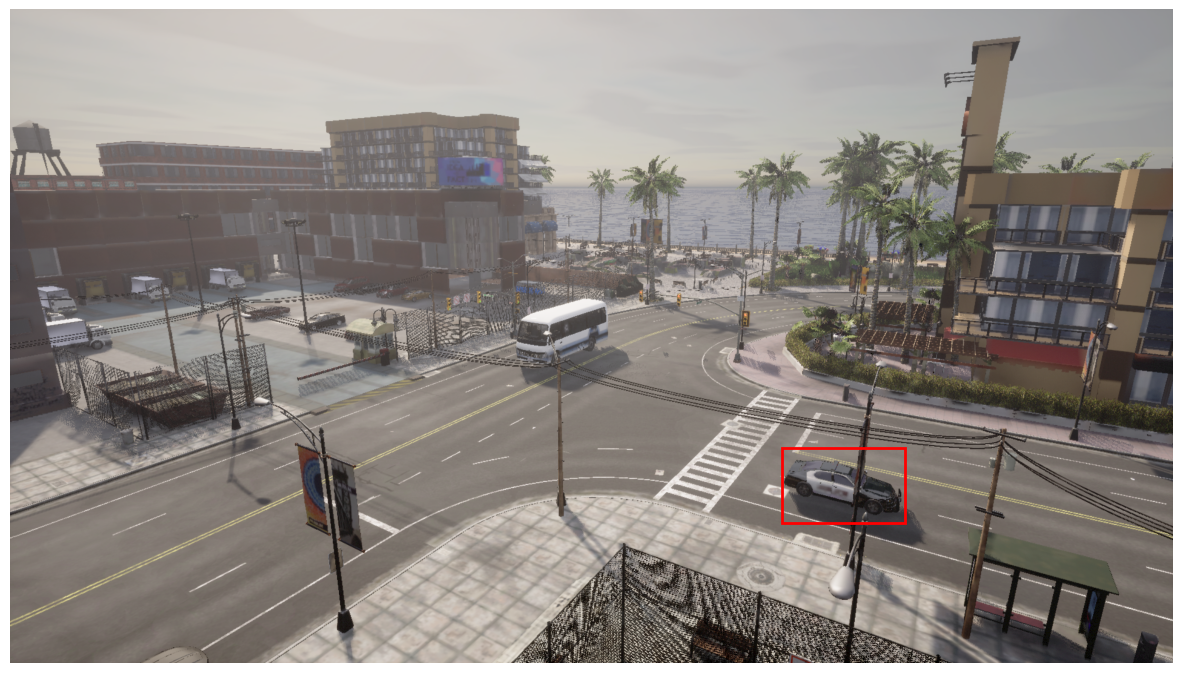

In [ ]:
# Function to load and visualize an image with bbox based on annotation id
def visualize_image_by_annotation_id(annotation_id):
    # Get the annotation info
    annotation = annotations[annotations['id'] == annotation_id].iloc[0]
    image_id = annotation['image_id']
    bbox = annotation['bbox']

    # Get the image info
    image_info = images[images['id'] == image_id].iloc[0]
    file_name = image_info['file_name']
    img_path = f'../train/{file_name}'  # Adjust the path accordingly

    # Read the image
    image = cv2.imread(img_path)
    if image is None:
        print(f"Image at path {img_path} not found.")
        return
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Draw the bbox
    fig, ax = plt.subplots(1, figsize=(15, 15))  # Increase the figure size
    ax.imshow(image)
    x, y, w, h = bbox
    rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

    # Check if bbox coordinates are within image dimensions
    height, width, _ = image.shape
    x1 = max(0, int(x))
    y1 = max(0, int(y))
    x2 = min(width, int(x + w))
    y2 = min(height, int(y + h))
    
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Example Usage
visualize_image_by_annotation_id(1)  # Use the appropriate annotation_i